# Using h-ABCD (implemented in Julia) from a Python Notebook

The following needs to be installed:
* The Julia language: ```https://julialang.org/downloads/```
* PyJulia: ```https://pypi.org/project/julia/```

To install the h-ABCD Julia package, open Julia REPL (the command line interface) and enter:
```
using Pkg
Pkg.add(url="https://github.com/bkamins/ABCDHypergraphGenerator.jl")
```


In [1]:
import julia               ## PyJulia, installed via: pip install julia
julia.install(quiet=True)  ## adding the path to the 'julia' executable may be needed
from julia.api import Julia 
jl = Julia(compiled_modules=False) ## needed on macOS (at least)
%load_ext julia.magic


Initializing Julia interpreter. This may take some time...


# Generate and visualize a small hypergraph 

* We use the Julia package ```ABCDHypergraphGenerator```
* In the following cell, the first line indicates that the cell contains Julia code.
* We generate the objects ```edges``` and ```clusters```, the h-ABCD hypergraph
 
The Julia API functions are:
 
* ABCDHypergaphGenerator.**sample_degrees**: sample degrees of vertices following power law
* ABCDHypergaphGenerator.**sample_communities**: sample community sizes following power law
* ABCDHypergaphGenerator.**ABCDHParams**: type holding information about sampled degrees, sampled cluster sizes and required mode of h-ABCD graph generation
* ABCDHypergaphGenerator.**gen_hypergraph**: h-ABCD graph generator that uses ABCDHParams specification
 

In [2]:
%%julia
using ABCDHypergraphGenerator
using Random

## seeding
seed = 1
Random.seed!(seed)

#############################################
## global parameters for the hABCD hypergraph
xi = 0.1
n = 50
max_iter = 1000
#############################################

#############################################
## degree sequence generation
gamma = 2.5
d_min = 3
d_max = 8
degs = ABCDHypergraphGenerator.sample_degrees(gamma, d_min, d_max, n);
#############################################

#############################################
## community sizes generation
beta = 1.5
c_min = 20
c_max = 30
coms = ABCDHypergraphGenerator.sample_communities(beta, c_min, c_max, n, max_iter)
@assert sum(coms) == n
#############################################

#############################################
## edge size distribution starting with edges of size 1
q = [0.0,1,1]
## should sum to one -- correct if needed
sq = sum(q)
if sq != 1
    q ./= sq
end

## edge "purity" weights wcd
purity = "linear" ## choices are: 'strict', 'linear' and 'majority'
wcd = zeros(Float64, length(q), length(q))
if purity == "strict"
    for d in 1:length(q)
        wcd[d, d] = 1.0
    end
elseif purity == "linear"
    for d in 1:length(q)
        for c in div(d, 2)+1:d
            wcd[c, d] = c
        end
        wcd[:, d] ./= sum(wcd[:, d])
    end
elseif purity == "majority"
    for d in 1:length(q)
        for c in div(d, 2)+1:d
            wcd[c, d] = 1.0 / (d-div(d, 2))
        end
    end
end
## if you know what you are doing, you can also specify the weights directly,
## for example:
## wcd = [1. 0. 0. ; 0. 1. 0.4 ; 0. 0. 0.6]
#############################################

## generate ABCD-oo graph
p = ABCDHypergraphGenerator.ABCDHParams( degs, coms, xi, q, wcd, true, max_iter);
edges, clusters = ABCDHypergraphGenerator.gen_hypergraph(p);


[ Info: Moving 1 stumps from community 2 to background graph
[ Info: fixing 3 hyperedges (3.53% of total number of hyperedges) that were multisets


## Plot the above graph using Python

We build an ```hypernetx``` object and the corresponding 2-section ```igraph``` graph, and plot those.


In [3]:
from julia import Main as jl ## to get the Julia variables in Python code
import igraph as ig
import hypernetx as hnx
import hypernetx.algorithms.hypergraph_modularity as hmod 
import xgi
import numpy as np
from collections import Counter 
import matplotlib.pyplot as plt
import random


In [4]:
## get the edges and builf HyperNetX hypergraph H
Edges = list(jl.edges)
Edges = [[int(i-1) for i in j] for j in Edges] ## recall Julia is 1-based
H = hnx.Hypergraph(dict(enumerate(Edges)))
print('distribution of edge sizes:',Counter([len(x) for x in Edges]))


distribution of edge sizes: Counter({2: 53, 3: 32})


In [5]:
## read the ground-truth communities; also assign node colors accordingly
comm = [int(x-1) for x in list(jl.clusters)] ## recall Julia is 1-based
cls = ['red','blue','green']
node_colors = dict(zip([int(i) for i in H.nodes], [cls[comm[i]] for i in H.nodes]))


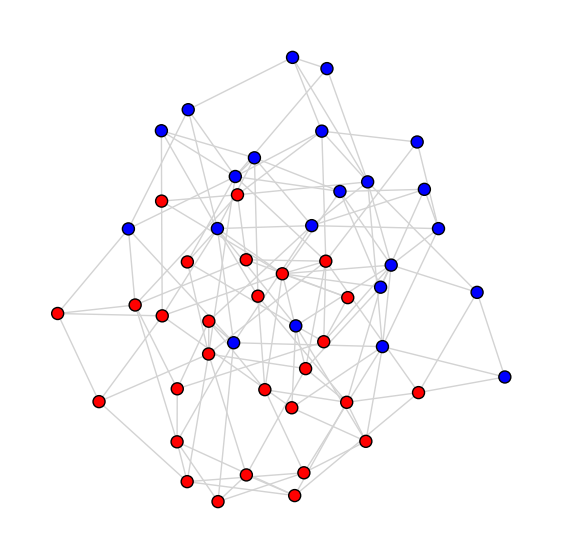

In [6]:
## build the 2-section graph and plot (with ground-truth community colors)
g = hmod.two_section(H)
for v in g.vs:
    v['color'] = node_colors[v['name']]
ly = g.layout_fruchterman_reingold()
fig, ax = plt.subplots(figsize=(7,7))
ig.plot(g, target=ax, vertex_size=12, layout=ly, edge_color='lightgrey', edge_width=1)
plt.show()


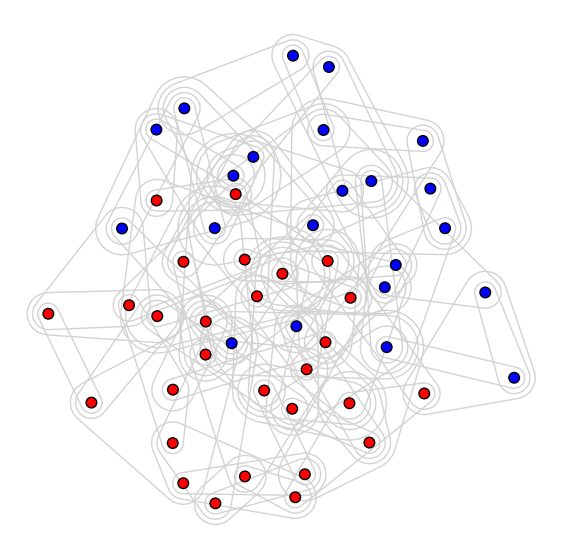

In [7]:
## rubber band plot with HyperNetx
random.seed(123)
H_ly = dict(zip(g.vs['name'], [[x[0],x[1]] for x in ly]))
fig, ax = plt.subplots(figsize=(7,7))
hnx.draw(H, with_node_labels=False, with_edge_labels=False, node_radius=.9,
         nodes_kwargs={'facecolors': node_colors, 'edgecolors' : 'black'},
         edges_kwargs={'edgecolors': 'lightgrey'},
         pos=H_ly)
plt.show()


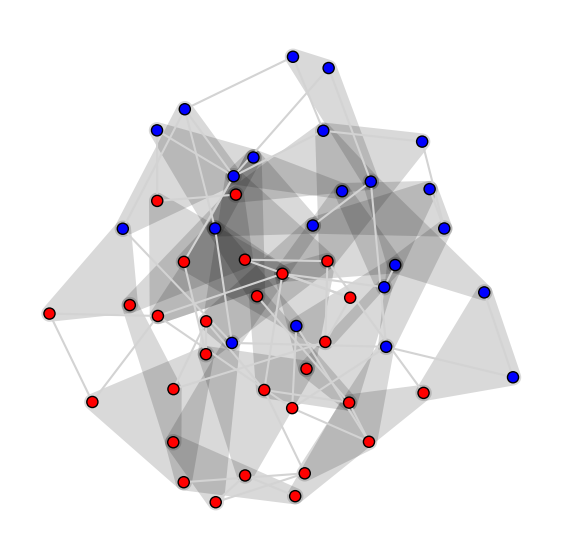

In [8]:
### Plot via convex hull with the XGI package
H_nc = dict(zip(g.vs['name'], g.vs['color']))
fig, ax = plt.subplots(figsize=(7,7))
XH = xgi.Hypergraph(Edges)
xgi.draw(XH, node_fc=H_nc, dyad_color='lightgrey', hull=True, radius=.15, edge_fc_cmap='Greys_r', 
         alpha=.15, pos=H_ly, node_size=8, ax=ax, node_labels=False )
plt.show()
